In [ ]:
# ===============================
# Install compatible libraries
# ===============================
!pip uninstall -y scikit-learn umap-learn cuml-cu12 || true

!pip install -U \
    scikit-learn==1.4.2 \
    tensorflow==2.19.0 \
    ml_dtypes>=0.5.0 \
    opencv-python \
    seaborn \
    matplotlib \
    tqdm \
    tensorflow-hub \
    imbalanced-learn

# Verify versions
import sklearn, tensorflow as tf
print("✅ scikit-learn:", sklearn.__version__)
print("✅ TensorFlow:", tf.__version__)


Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: umap-learn 0.5.11
Uninstalling umap-learn-0.5.11:
  Successfully uninstalled umap-learn-0.5.11
Found existing installation: cuml-cu12 25.10.0
Uninstalling cuml-cu12-25.10.0:
  Successfully uninstalled cuml-cu12-25.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
✅ scikit-learn: 1.4.2
✅ TensorFlow: 2.19.0


In [ ]:
# ===============================
# General & Data Libraries
# ===============================
import os, glob, json, random, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import load_img, img_to_array, to_categorical

# Image processing
import cv2
from tqdm import tqdm

# Data balancing
from imblearn.over_sampling import RandomOverSampler

# Visualization
sns.set_style("darkgrid")
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Imports & seeds set")


✅ Imports & seeds set


In [ ]:
from google.colab import drive

print("⚙️ Mounting Drive...")
drive.mount('/content/drive')
print("✅ Drive mounted")

# ===============================
# Paths & Constants
# ===============================
DATA_ROOTS = [
    "/content/drive/MyDrive/CSE-51/8Th/Capstone/Capstone 2.0/Breast Cancer New Dataset"
]

OUT_DIR = "/content/drive/MyDrive/CSE-51/8Th/Capstone/Capstone/Breast_Models_API"
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 64

CLASSES = ["normal", "benign", "malignant"]
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("✅ Paths & constants ready")


⚙️ Mounting Drive...
Mounted at /content/drive
✅ Drive mounted
✅ Paths & constants ready


In [ ]:
# -------------------------
# 1) Dataset collection (re-added)
# -------------------------
import os, glob, random
import numpy as np
from collections import Counter
import cv2
import tensorflow as tf # Required for tf.TensorSpec
from tensorflow.keras.utils import to_categorical # Required for one-hot encoding
from imblearn.over_sampling import RandomOverSampler # Required for data balancing
from sklearn.model_selection import train_test_split

# Define paths and constants locally for self-containment
DATA_ROOTS = [
    "/content/drive/MyDrive/CSE-51/8Th/Capstone/Capstone 2.0/Breast Cancer New Dataset"
]
IMG_SIZE   = (224, 224)
BATCH_SIZE = 64
CLASSES = ["normal", "benign", "malignant"]
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
SEED = 42 # Added SEED definition for self-containment

def is_mask_path(p):
    name = os.path.basename(p).lower()
    return ("mask" in name) or name.endswith("_mask.png") or name.endswith("_gt.png")

def collect_dataset(data_roots):
    paths, labels, mask_paths = [], [], []
    for root in data_roots:
        for cls in CLASSES:
            cdir = os.path.join(root, cls)
            if not os.path.isdir(cdir):
                continue
            imgs = []
            for ext in ("*.png","*.jpg","*.jpeg"):
                imgs += glob.glob(os.path.join(cdir, ext))
            imgs = [p for p in imgs if not is_mask_path(p)]
            for p in imgs:
                stem = os.path.splitext(os.path.basename(p))[0].lower()
                folder = os.path.dirname(p)
                mask = ""
                for ext in ("*.png","*.jpg","*.jpeg"):
                    for m in glob.glob(os.path.join(folder, ext)):
                        if "mask" in m.lower() and stem in m.lower():
                            mask = m
                            break
                paths.append(p)
                labels.append(class_to_idx[cls])
                mask_paths.append(mask)
    return np.array(paths), np.array(labels), np.array(mask_paths)

paths, labels, mask_paths = collect_dataset(DATA_ROOTS)
assert len(paths)>0, "❌ No images found. Check DATA_ROOTS or class folder names!"
print(f"🧾 Total images: {len(paths)} | mask coverage \u2248 {np.mean(mask_paths!='')*100:.1f}%")

# ------------------------- Original code begins here
# 2) Split dataset
# -------------------------
X_temp, X_test, y_temp, y_test, m_temp, m_test = train_test_split(
    paths, labels, mask_paths, test_size=0.15, stratify=labels, random_state=SEED
)
X_train, X_val, y_train, y_val, m_train, m_val = train_test_split(
    X_temp, y_temp, m_temp, test_size=0.1765, stratify=y_temp, random_state=SEED
)
print(f"Split \u2192 train={len(X_train)} | val={len(X_val)} | test={len(X_test)}")

# -------------------------
# 2.1) Balance training data using RandomOverSampler (New)
# -------------------------
print("Balancing training data...")
ros = RandomOverSampler(random_state=SEED)
# Reshape X_train (paths, masks) for oversampler, then unpack
X_train_resampled_indices, y_train_resampled = ros.fit_resample(np.arange(len(X_train)).reshape(-1, 1), y_train)
X_train_resampled_indices = X_train_resampled_indices.flatten()

X_train_bal = X_train[X_train_resampled_indices]
y_train_bal = y_train_resampled
m_train_bal = m_train[X_train_resampled_indices]

print(f"Original training class distribution: {Counter(y_train)}")
print(f"Resampled training class distribution: {Counter(y_train_bal)}")

# -------------------------
# 2.2) One-hot encode labels (New)
# -------------------------
num_classes = len(CLASSES)
y_train_ohe = to_categorical(y_train_bal, num_classes=num_classes)
y_val_ohe   = to_categorical(y_val, num_classes=num_classes)
y_test_ohe  = to_categorical(y_test, num_classes=num_classes)
print("Labels one-hot encoded.")


# -------------------------
# 3) Helper functions
# -------------------------
def load_image_bgr(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    return img if img is not None else np.zeros((224,224,3), np.uint8)

def load_mask(mask_path, base_img):
    if mask_path and os.path.exists(mask_path):
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        _, mb = cv2.threshold(m, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
        return (mb>0).astype(np.uint8)
    else:
        return np.zeros(base_img.shape[:2], np.uint8)

def roi_from_mask(img_bgr, mask_bin):
    if mask_bin.sum()==0: return img_bgr
    ys, xs = np.where(mask_bin>0)
    y0, y1 = max(ys.min()-10,0), min(ys.max()+10, img_bgr.shape[0]-1)
    x0, x1 = max(xs.min()-10,0), min(xs.max()+10, img_bgr.shape[1]-1)
    return img_bgr[y0:y1+1, x0:x1+1]

def to_tensor(img_bgr, size=IMG_SIZE):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, size, interpolation=cv2.INTER_AREA)
    return img_rgb.astype(np.float32)/255.0

# -------------------------
# 4) Dataset generator
# -------------------------
def gen_dataset(X, y_ohe, M, training=True):
    idxs = np.arange(len(X))
    if training: np.random.shuffle(idxs)
    for i in idxs:
        img = load_image_bgr(X[i])
        mask = load_mask(M[i], img)
        roi = roi_from_mask(img, mask)
        arr = to_tensor(roi)
        if training:
            if random.random()<0.5: arr = arr[:, ::-1, :]
            if random.random()<0.2: arr = np.clip(arr + np.random.uniform(-0.08,0.08), 0,1)
        yield arr, y_ohe[i]

sig = (tf.TensorSpec(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), dtype=tf.float32),
       tf.TensorSpec(shape=(num_classes,), dtype=tf.float32)) # Updated for one-hot encoding

def build_tfds(X, y_ohe, M, training):
    ds = tf.data.Dataset.from_generator(lambda: gen_dataset(X,y_ohe,M,training), output_signature=sig)
    if training: ds = ds.shuffle(1024)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

ds_train = build_tfds(X_train_bal, y_train_ohe, m_train_bal, True)
ds_val   = build_tfds(X_val,   y_val_ohe,   m_val,   False)
ds_test  = build_tfds(X_test,  y_test_ohe,  m_test,  False)


🧾 Total images: 8088 | mask coverage ≈ 0.0%
Split → train=5660 | val=1214 | test=1214
Balancing training data...
Original training class distribution: Counter({np.int64(2): 2049, np.int64(1): 1948, np.int64(0): 1663})
Resampled training class distribution: Counter({np.int64(2): 2049, np.int64(1): 2049, np.int64(0): 2049})
Labels one-hot encoded.


In [ ]:
# ===============================
# 5) Define Custom CNN Model
# ===============================

# Ensure IMG_SIZE and CLASSES are defined in this scope
IMG_SIZE   = (224, 224)
CLASSES = ["normal", "benign", "malignant"]

# Explicitly import Keras components needed in this cell
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
import tensorflow.keras as keras # Added this import

def create_cnn_model(input_shape, num_classes, l2_reg=0.001):
    model = Sequential([
        # First Convolutional Block
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same',
               kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Flatten and Dense Layers
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Instantiate and compile the custom CNN model
custom_cnn_model = create_cnn_model(IMG_SIZE + (3,), num_classes=len(CLASSES))

custom_cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn_model.summary()
print("✅ Custom CNN model with L2 regularization defined and compiled.")

# Note: This model is separate from the EfficientNetB3 model in a later cell.
# If you intend to use this custom CNN for training, you will need to replace
# 'model' and its training calls in subsequent cells with 'custom_cnn_model'.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,307 (98.37 MB)

 Trainable params: 25,785,347 (98.36 MB)

 Non-trainable params: 960 (3.75 KB)

✅ Custom CNN model with L2 regularization defined and compiled.


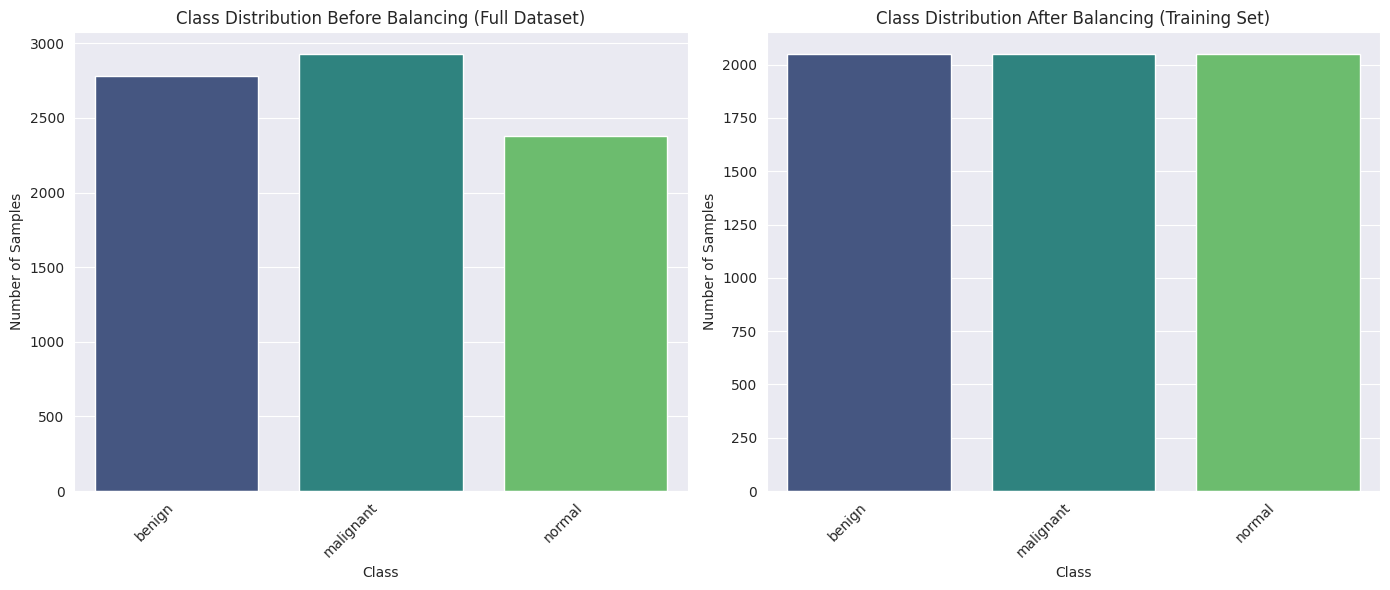

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# --- Visualize Class Distribution Before Balancing ---
original_class_counts = Counter(labels)
original_df = pd.DataFrame({
    'Class': [idx_to_class[i] for i in original_class_counts.keys()],
    'Count': list(original_class_counts.values())
}).sort_values(by='Class')

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Class', y='Count', data=original_df, hue='Class', palette='viridis', legend=False)
plt.title('Class Distribution Before Balancing (Full Dataset)')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')

# --- Visualize Class Distribution After Balancing ---
balanced_class_counts = Counter(y_train_bal)
balanced_df = pd.DataFrame({
    'Class': [idx_to_class[i] for i in balanced_class_counts.keys()],
    'Count': list(balanced_class_counts.values())
}).sort_values(by='Class')

plt.subplot(1, 2, 2)
sns.barplot(x='Class', y='Count', data=balanced_df, hue='Class', palette='viridis', legend=False)
plt.title('Class Distribution After Balancing (Training Set)')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Ensure these global variables are accessible or passed as arguments if not global
# Assuming IMG_SIZE, CLASSES, num_classes, ds_train, ds_val, ds_test, y_test_ohe are defined

def train_and_evaluate_model(base_model_constructor, model_name, checkpoint_path, IMG_SIZE, CLASSES, num_classes, ds_train, ds_val, ds_test, y_test_ohe):
    print(f"\n--- Training and Evaluating {model_name} ---")

    # 1. Define Callbacks
    callbacks = [
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
    ]

    # 2. Build the Transfer Learning Model
    base_model = base_model_constructor(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )

    # Freeze the layers of the base model
    base_model.trainable = False

    # Add custom classification layers on top
    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)), # Added L2 regularization
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name=model_name)

    # 3. Compile the model (initial compilation with frozen base)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\n--- Phase 1: Training {model_name} (Frozen Base) ---")
    history_phase1 = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=20, # Initial training epochs
        callbacks=callbacks,
        verbose=1
    )

    # 4. Implement Fine-tuning
    print(f"\n--- Phase 2: Fine-tuning {model_name} (Unfrozen Top Layers) ---")
    # Unfreeze a portion of the base model's top layers
    # A common strategy is to unfreeze the last few layers of the base model
    # Adjust this number based on the specific base model and dataset
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    # Recompile the model with a lower learning rate for fine-tuning
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Significantly lower learning rate
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_phase2 = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=30, # Additional epochs for fine-tuning
        callbacks=callbacks,
        verbose=1
    )

    # Combine histories for plotting
    history = {
        'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
        'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
        'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
        'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss']
    }

    # 5. Load the best saved model
    print(f"\n--- Loading best {model_name} model from {checkpoint_path} ---")
    best_model = keras.models.load_model(checkpoint_path)

    # 6. Evaluate the best model on the test set
    print(f"\n--- Evaluating {model_name} on Test Data ---")
    test_loss, test_acc = best_model.evaluate(ds_test, verbose=0)
    print(f"✅ {model_name} Test accuracy: {test_acc:.3f} | loss: {test_loss:.3f}")

    # 7. Plot Training Metrics
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()

    # 8. Generate predictions and display classification report & confusion matrix
    print(f"\n--- Classification Report for {model_name} ---")
    y_pred_probs = best_model.predict(ds_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_ohe, axis=1)

    print(classification_report(y_true, y_pred, target_names=CLASSES))

    print(f"\n--- Confusion Matrix for {model_name} ---")
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.show()

    return best_model, history

print("✅ `train_and_evaluate_model` function defined.")


✅ `train_and_evaluate_model` function defined.



--- Training and Evaluating EfficientNetB3 ---
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Phase 1: Training EfficientNetB3 (Frozen Base) ---
Epoch 1/20
     97/Unknown 2651s 21s/step - accuracy: 0.3476 - loss: 2.0841
Epoch 1: val_accuracy improved from -inf to 0.34432, saving model to /content/drive/MyDrive/CSE-51/8Th/Capstone/Capstone/Breast_Models_API/efficientnet_best.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 3220s 27s/step - accuracy: 0.3477 - loss: 2.0831 - val_accuracy: 0.3443 - val_loss: 6.6260 - learning_rate: 0.0010
Epoch 2/20
96/97 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3745 - loss: 1.6995
Epoch 2: val_accuracy did not improve from 0.34432
97/97 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.3745 - loss: 1.6983 - val_accuracy: 0.3443 - val_loss: 4.0610 - learning_rate: 0.0010
Epoch 3/20
96/97 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3653 - loss: 1.5278
Epoch 3: val_accuracy did not improve from 0.34432
97/97 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.36

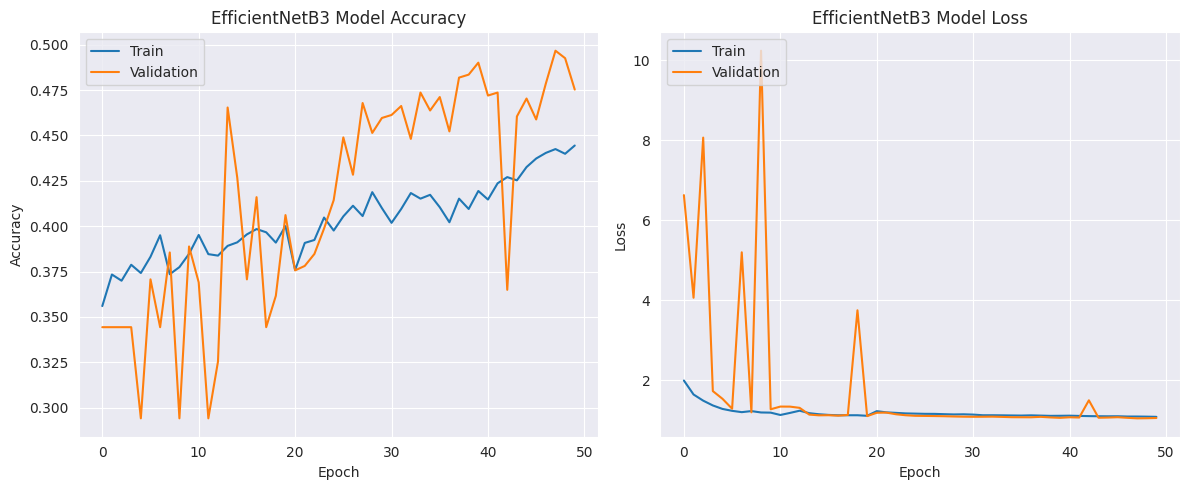


--- Classification Report for EfficientNetB3 ---
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step
              precision    recall  f1-score   support

      normal       0.44      0.55      0.49       357
      benign       0.48      0.32      0.38       418
   malignant       0.56      0.62      0.59       439

    accuracy                           0.50      1214
   macro avg       0.49      0.50      0.49      1214
weighted avg       0.50      0.50      0.49      1214


--- Confusion Matrix for EfficientNetB3 ---


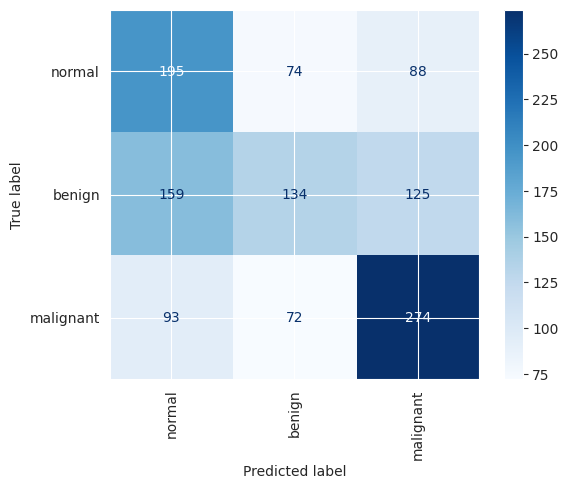

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
import os

# 2. Define a variable efficientnet_model_name
efficientnet_model_name = 'EfficientNetB3'

# 3. Define a variable efficientnet_checkpoint_path
efficientnet_checkpoint_path = os.path.join(OUT_DIR, "efficientnet_best.keras")

# 4. Call the train_and_evaluate_model function
best_efficientnet_model, history_efficientnet = train_and_evaluate_model(
    base_model_constructor=EfficientNetB3,
    model_name=efficientnet_model_name,
    checkpoint_path=efficientnet_checkpoint_path,
    IMG_SIZE=IMG_SIZE,
    CLASSES=CLASSES,
    num_classes=num_classes,
    ds_train=ds_train,
    ds_val=ds_val,
    ds_test=ds_test,
    y_test_ohe=y_test_ohe
)



--- Training and Evaluating Xception ---
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Phase 1: Training Xception (Frozen Base) ---
Epoch 1/20
     97/Unknown 171s 1s/step - accuracy: 0.5880 - loss: 2.1023
Epoch 1: val_accuracy improved from -inf to 0.70099, saving model to /content/drive/MyDrive/CSE-51/8Th/Capstone/Capstone/Breast_Models_API/xception_best.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.5885 - loss: 2.1006 - val_accuracy: 0.7010 - val_loss: 1.5834 - learning_rate: 0.0010
Epoch 2/20
96/97 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7128 - loss: 1.4514
Epoch 2: val_accuracy improved from 0.70099 to 0.72076, saving model to /content/drive/MyDrive/CSE-51/8Th/Capstone/Capstone/Breast_Models_API/xception_best.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.7129 - loss: 1.4504 - val_accuracy: 0.7208 - val_loss: 1.2279 - learning_rate: 0.0010
Epoch 3/20
96/97 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7473 - loss: 1.2174
Epoch 3: val_acc

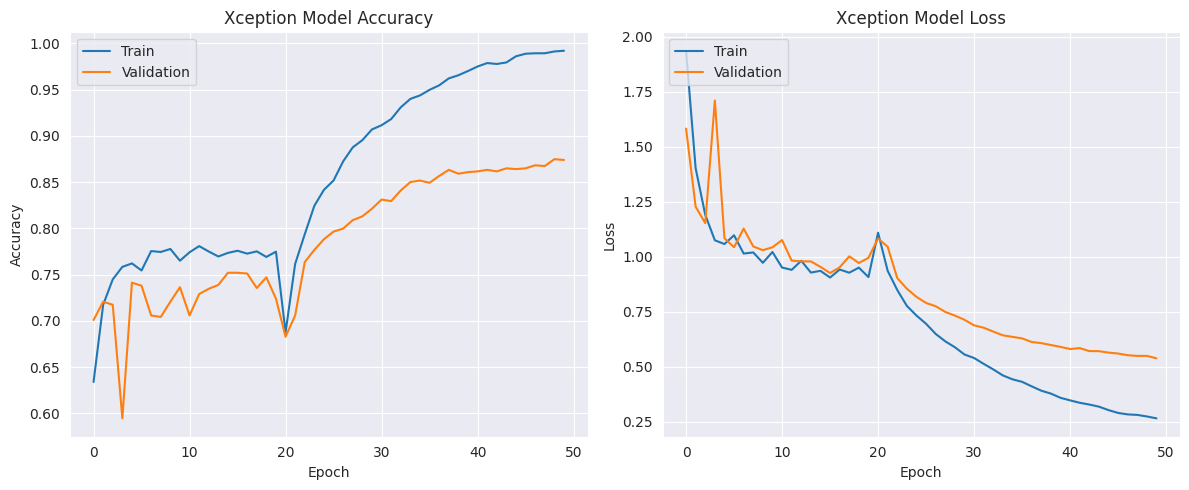


--- Classification Report for Xception ---
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step
              precision    recall  f1-score   support

      normal       0.88      0.95      0.91       357
      benign       0.83      0.76      0.79       418
   malignant       0.84      0.85      0.85       439

    accuracy                           0.85      1214
   macro avg       0.85      0.85      0.85      1214
weighted avg       0.85      0.85      0.85      1214


--- Confusion Matrix for Xception ---


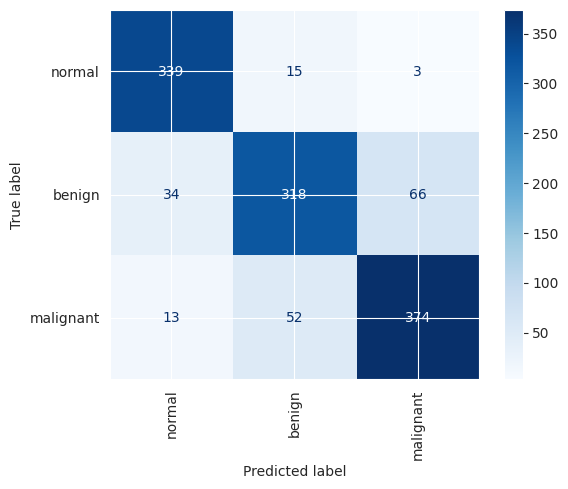

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
import os

# Define model name and checkpoint path for Xception
xception_model_name = 'Xception'
xception_checkpoint_path = os.path.join(OUT_DIR, "xception_best.keras")

# Call the train_and_evaluate_model function for Xception
best_xception_model, history_xception = train_and_evaluate_model(
    base_model_constructor=Xception,
    model_name=xception_model_name,
    checkpoint_path=xception_checkpoint_path,
    IMG_SIZE=IMG_SIZE,
    CLASSES=CLASSES,
    num_classes=num_classes,
    ds_train=ds_train,
    ds_val=ds_val,
    ds_test=ds_test,
    y_test_ohe=y_test_ohe
)
